<a href="https://colab.research.google.com/github/Suvanga/ML_DL/blob/main/Workflows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

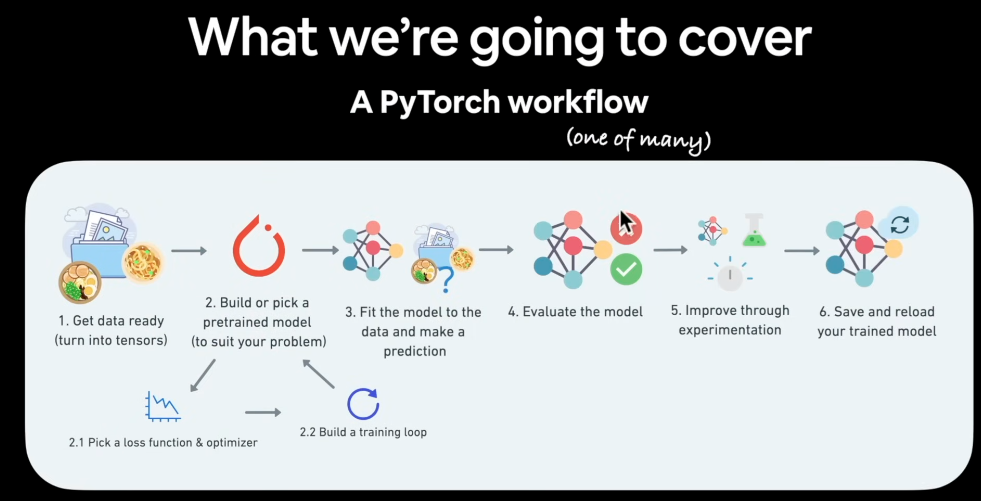


In [395]:
Things_to_cover = {1:"data(prepare and load)",
                   2: "build a model",
                   3: "fitting the model to the data which is called training",
                   4: "making predictions and evaluating a model( inference )",
                   5: "saving and learning a model",
                   6: "Putting it all at one place together"}
Things_to_cover


{1: 'data(prepare and load)',
 2: 'build a model',
 3: 'fitting the model to the data which is called training',
 4: 'making predictions and evaluating a model( inference )',
 5: 'saving and learning a model',
 6: 'Putting it all at one place together'}

In [396]:
import torch
from torch import nn #nn contains all of the pytorch building blocks
import matplotlib.pyplot as plt


##Preparing and Loading
* Data can be almost anything in machine  learning could be
  * Excel
  * Spreadsheer,
  * Images of any kind,
  * youtube has a lots of data
  * Audio
  * Patents of DNA is being used LOL
  * Text

## this has 2 parts
1. Get data into a numerical representaion
2. Buuild a model to represebt a patterns in that numerical representation


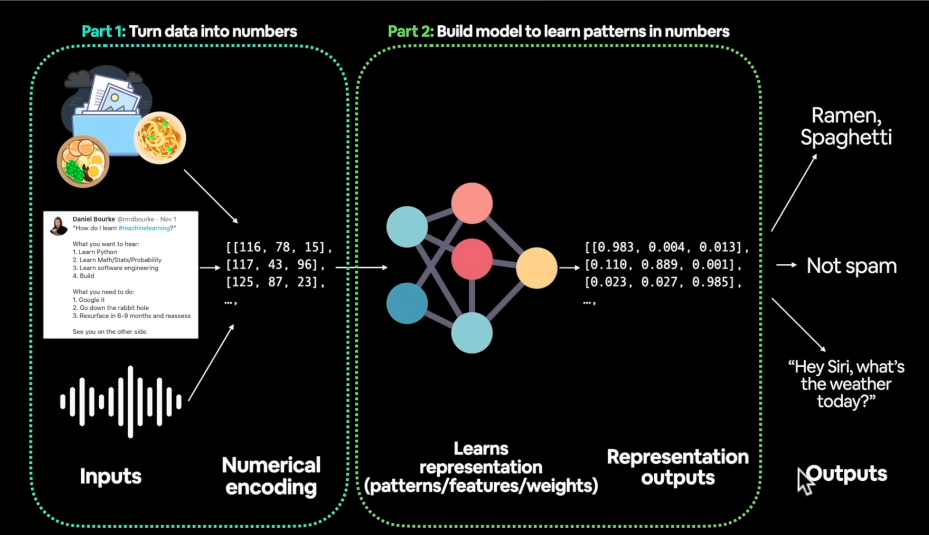

In [397]:
#Create a *Known* parameters here is the formula Y = a +bx
weight = 0.7 ## that is our weight b
bias = 0.3  ## bias will be a

#create
start =0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim =1)
y = weight*X+ bias

In [398]:
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [399]:
len(X), len(y)

(50, 50)

###Splitting data into train and test steps

* Possibly the most important material in the machine learning

In [400]:
#Create a train test split
train_split = int(0.8*len(X))
train_split

train_X, train_y = X[:train_split], y[:train_split]
test_X, test_y = X[train_split:], y[train_split:]

In [401]:
def plot_predictions(train_data = train_X,
                     train_labels =train_y,
                     test_data = test_X,
                     test_labels = test_y,
                     predictions=None):

  plt.figure(figsize=(10,7))
  plt.scatter(train_data,train_labels, c="b",s=4, label = "Training Data")

  #plot tresting fdata with green
  plt.scatter(test_data, test_labels, c="g", s= 4, label = "Testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label = "Predictions")

  plt.legend(prop = {"size":14});

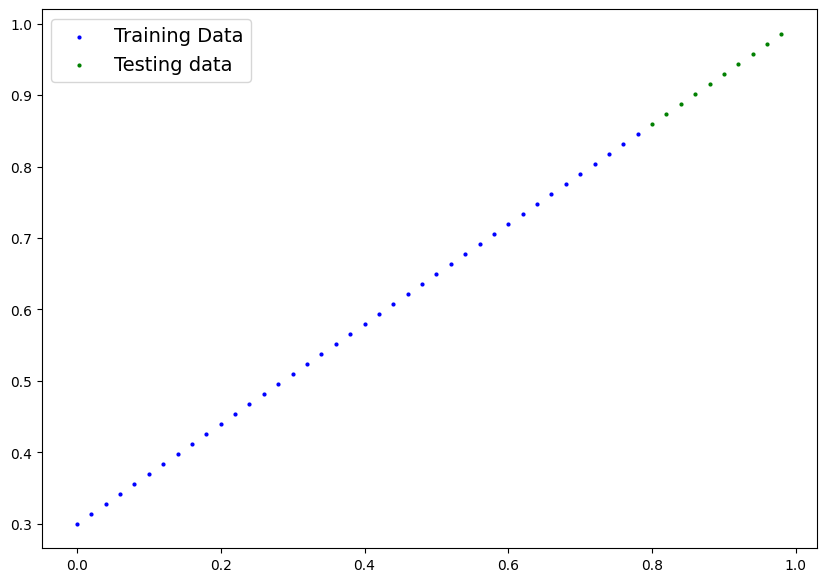

In [402]:
plot_predictions()

In [403]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                           requires_grad=True,
                                           dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))

    #Forward method to define the computation in the model
  def forward(self, x: torch.Tensor)-> torch.Tensor:
      return self.weights * x + self.bias

###Pytorch building model essentials

* torch.nn: The namespace containing all the building blocks for creating computational graphs (neural networks).

* torch.nn.Module: The base class that all neural network modules must inherit from to function correctly.

* torch.nn.Parameter: A wrapper for tensors that tells PyTorch to track gradients so the parameters can be updated during training.

* forward(): The mandatory method you must define in your class to specify the computation step (how data moves through the model).

*

In [404]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [405]:
##We can also list the nae parameter
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [406]:
weight , bias

test_y

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

In [407]:
with torch.inference_mode():
  y_preds = model_0(test_X)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

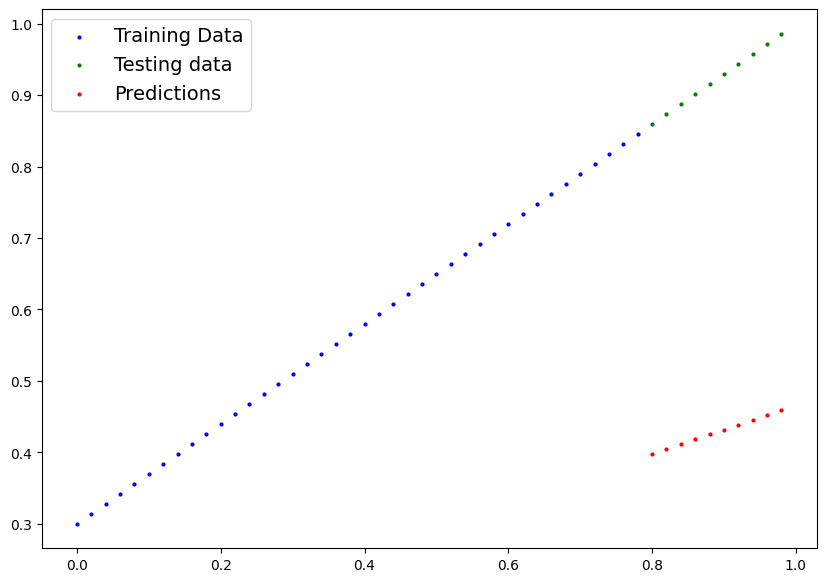

In [408]:
##Lets visualize them
plot_predictions(predictions =y_preds)

##Train Model
* for a model to move from unknown parameters to the known paramters, simply saying poor representation ofdata to a better represenatation of the data
* One way to measure how wrong ,y mpodels predictions are to use the loss funcition
* Note function AKA cost function/Criterion
* In our casee we are going to define as loss function

Things we need to train
* Loss Function
  * A function to measure how wrong the model predictions are to the ideal outputs

* Optimizer
  *  Takes into account the loss of a model and adjusts the model's parameters

  Specifically with pytorch we need two basic steps:
  * A training loop
  * A testing loop

  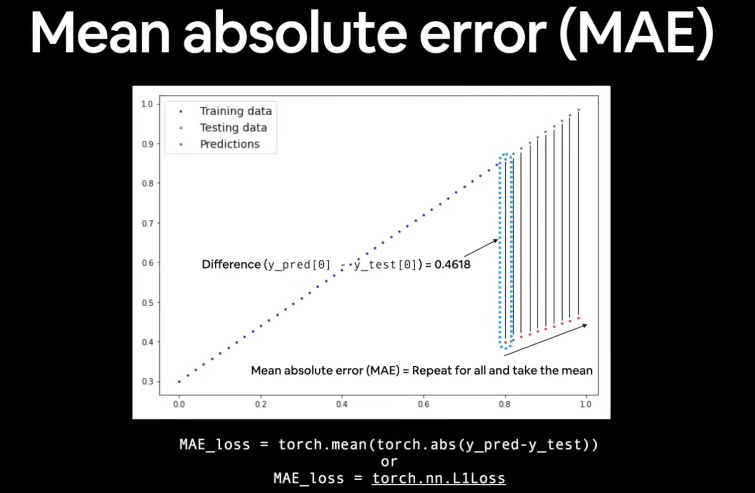

In [409]:
model_0.state_dict() ## basically trying to change the weights and bias towards the values that lowers the loss function

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [410]:
## Setting up a training and testing a machine learning model
##setting up a loss function
loss_fn =torch.nn.L1Loss() #LAsso

#setting up an optimizer to minimize the distance get the MAE Lower, which is the ideal pooint for our model to be
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.01) #LR represents learning rate

model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

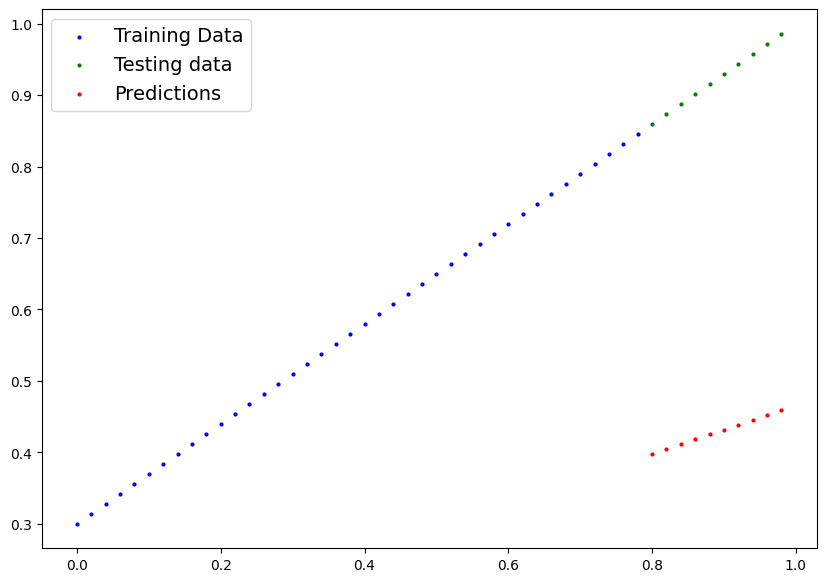

In [411]:
plot_predictions(predictions =y_preds)

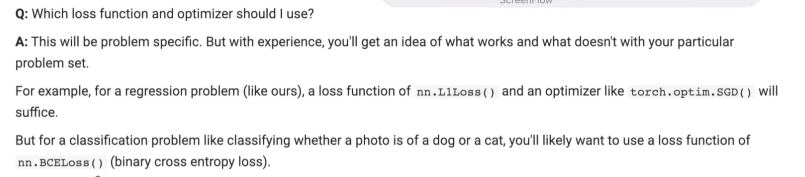

###Building a training loop and a testing loop with pytorch
##Loop throgh the data
0. Loop throught the data
1. Forward Pass( Data moving through our forward function) also called forward propogation
2. Calculate the Loss (compare forward pass predictions to ground truth labels )
3. Optimizer zero grad4
4. Loss Backward-> move backwards through the network to calculate the gradients
    each of the parameters of our models wirh respect to the loss AKA back propagation
5. Optimizer step use the optimizer to asjust our mmodel;s parameters to try and improve loss
6.

In [412]:
with torch.inference_mode():
  list(model_0.parameters())

In [418]:
#An epoch ins one loop through data and this is a hyperparameter

torch.manual_seed(42)
epochs = 1




  #0 Loop through the data
for epoch in range(epochs):
    model_0.train()

  #1 Forward pass
    y_pred = model_0(train_X)
    # print(y_pred)

  #2 Calculate the loss
    loss = loss_fn(y_pred, train_y)
  # print(loss)

  #3 Optimizer zero grad as they accumulate by default,
    optimizer.zero_grad()

  #4 perform back propagation in the loss with respect to the parameters of the model
    loss.backward()

  #5 Ste[ the optimizer which means perform gradient descent]
    optimizer.step() # //This is where the gradient descent is hapening

    model_0.eval() #Turns of gradient tracking


In [414]:
model_0.state_dict()


OrderedDict([('weights', tensor([0.3562])), ('bias', tensor([0.1788]))])

In [415]:
model_0.eval()



LinearRegressionModel()

In [416]:
# #An epoch ins one loop through data and this is a hyperparameter
# import time
# torch.manual_seed(42)
# epochs = 100000
# delay_graph = 5


# for delay in range(delay_graph):
#   #0 Loop through the data
#   for epoch in range(epochs):
#     model_0.train()

#   #1 Forward pass
#     y_pred = model_0(train_X)
#     # print(y_pred)

#   #2 Calculate the loss
#   loss = loss_fn(y_pred, train_y)
#   # print(loss)

#   #3 Optimizer zero grad as they accumulate by default,
#   optimizer.zero_grad()

#   #4 perform back propagation in the loss with respect to the parameters of the model
#   loss.backward()

#   #5 Ste[ the optimizer which means perform gradient descent]
#   optimizer.step() # //This is where the gradient descent is hapening

#   model_0.eval() #Turns of gradient tracking
#   with torch.inference_mode():
#     y_trends = model_0(test_X)
#     plot_predictions(predictions=y_trends)
#   time.sleep(1)